In [1]:
import numpy as np
import pandas as pd
import cobra
from cobra.io import read_sbml_model
import matplotlib.pyplot as plt
import seaborn as sns
from cobra import Model, Reaction, Metabolite
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import random
from scipy import stats
from scipy.stats import mannwhitneyu, kruskal
from sklearn.preprocessing import normalize, LabelEncoder, MinMaxScaler
from upsetplot import UpSet, from_memberships

In [2]:
#import stationary/death phase CHO model (iCHO2441 with transcriptomics integrated): https://doi.org/10.1002/bit.28982
%store -r constrained_111214
model = constrained_111214

#### Figure 1e

In [3]:
#generate a dataframe of random objective functions
reaction_ids = []
for r in model.reactions:
    reaction_ids.append(r.id)

growth = model.reactions.get_by_id('biomass_cho_prod')
igg = model.reactions.get_by_id('ICproduct_TRANSLATION_protein')
glucose = model.reactions.get_by_id('EX_glc(e)')
glutamine = model.reactions.get_by_id('EX_gln_L(e)')
ammonia = model.reactions.get_by_id('EX_nh4(e)')
lactate = model.reactions.get_by_id('EX_lac_L(e)')

flux_df = pd.DataFrame()
flux_df['reaction_ids'] = reaction_ids
flux_df = flux_df.set_index('reaction_ids')

labels = ["growth", "igg", "glucose", "glutamine", "ammonia", "lactate"]

for i in range(500):
    coefficients = [random.uniform(-1, 1) for _ in range(6)]
    abs_sum = sum(abs(c) for c in coefficients)
    coefficients = [c / abs_sum for c in coefficients]
    objective_dict = {
        growth: coefficients[0],
        igg: coefficients[1],
        glucose: coefficients[2],
        glutamine: coefficients[3],
        ammonia: coefficients[4],
        lactate: coefficients[5]
    }
    header = "{" + ", ".join(f"{name}:{coeff:.4f}" for name, coeff in zip(labels, coefficients)) + "}"

    with model:
        model.objective = objective_dict
        solution = model.optimize()
        fluxes = solution.fluxes.to_list()

    flux_df[header] = fluxes
flux_df

C:\Users\p04121km\AppData\Local\Temp\ipykernel_13748\3095744792.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  flux_df[header] = fluxes
C:\Users\p04121km\AppData\Local\Temp\ipykernel_13748\3095744792.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  flux_df[header] = fluxes
C:\Users\p04121km\AppData\Local\Temp\ipykernel_13748\3095744792.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at 

,"{growth:0.2627, igg:0.1774, glucose:0.2654, glutamine:-0.0019, ammonia:0.1613, lactate:-0.1313}","{growth:-0.1340, igg:0.1728, glucose:0.0071, glutamine:-0.2261, ammonia:-0.2629, lactate:0.1970}","{growth:0.0915, igg:0.3635, glucose:-0.0688, glutamine:-0.2768, ammonia:0.0295, lactate:-0.1699}","{growth:-0.0572, igg:0.2041, glucose:0.1094, glutamine:-0.0149, ammonia:-0.1850, lactate:-0.4295}","{growth:-0.2485, igg:0.0587, glucose:0.0894, glutamine:0.1064, ammonia:-0.1649, lactate:0.3322}","{growth:0.2573, igg:0.1850, glucose:-0.0918, glutamine:-0.1456, ammonia:0.1933, lactate:0.1271}","{growth:-0.1468, igg:0.4825, glucose:0.1171, glutamine:-0.0239, ammonia:-0.0960, lactate:0.1336}","{growth:0.2498, igg:0.1499, glucose:0.2088, glutamine:-0.1918, ammonia:-0.1470, lactate:-0.0526}","{growth:0.1415, igg:-0.1928, glucose:0.2336, glutamine:-0.2448, ammonia:-0.0630, lactate:-0.1244}","{growth:0.2852, igg:-0.2700, glucose:0.0655, glutamine:-0.1666, ammonia:0.1557, lactate:-0.0570}",...,"{growth:-0.3044, igg:-0.1133, glucose:0.1604, glutamine:-0.1081, ammonia:0.2491, lactate:-0.0646}","{growth:0.2853, igg:0.1049, glucose:0.2314, glutamine:-0.1018, ammonia:-0.1060, lactate:0.1707}","{growth:0.1620, igg:0.2221, glucose:-0.2007, glutamine:0.1706, ammonia:-0.2250, lactate:-0.0195}","{growth:0.0508, igg:0.0433, glucose:0.0626, glutamine:-0.1618, ammonia:-0.3431, lactate:-0.3385}","{growth:-0.1725, igg:0.2428, glucose:-0.0892, glutamine:-0.1295, ammonia:0.1390, lactate:-0.2271}","{growth:0.2899, igg:-0.2138, glucose:-0.0291, glutamine:-0.2119, ammonia:0.1287, lactate:0.1266}","{growth:-0.1976, igg:-0.1347, glucose:-0.2751, glutamine:0.0859, ammonia:0.2574, lactate:0.0492}","{growth:-0.1929, igg:-0.2824, glucose:-0.0658, glutamine:-0.1808, ammonia:0.2041, lactate:0.0739}","{growth:-0.0023, igg:0.2502, glucose:0.2611, glutamine:-0.1670, ammonia:-0.1120, lactate:0.2074}","{growth:-0.3136, igg:0.0775, glucose:-0.0664, glutamine:-0.1336, ammonia:0.0495, lactate:0.3594}"
reaction_ids,,,,,,,,,,,,,,,,,,,,,
10FTHF5GLUtl,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0
10FTHF5GLUtm,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0
10FTHF6GLUtl,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0
10FTHF6GLUtm,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0
10FTHF7GLUtl,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
OST_complex,0.0,0.0,0.00006,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.710384e-05,0.0,6.048193e-05,0.0,0.0,0.0,0.0,0.0
Proteasome_degradation,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.061622e-21,0.0,1.224649e-20,0.0,0.0,0.0,0.0,0.0
DM_igg[g],0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.0,0.0,0.0,0.0,0.0


C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\p041

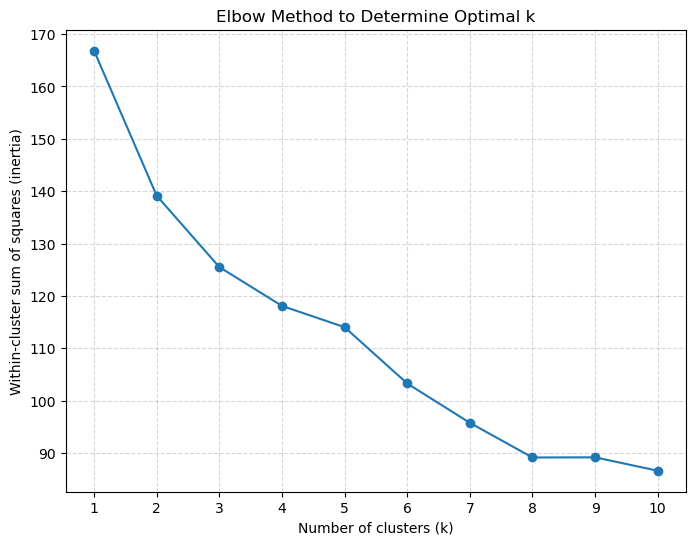

In [4]:
#determine optimal k frequency. (N.B. this will change with each run, so will look different from figure in paper)
inertia = []
k_values = range(1, 11)  # test k=1 to k=10

X = normalize(flux_df.T)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)  # sum of squared distances to cluster centers

# Plot the elbow plot
plt.figure(figsize=(8, 6))
plt.plot(k_values, inertia, marker='o')
plt.xticks(k_values)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Within-cluster sum of squares (inertia)')
plt.title('Elbow Method to Determine Optimal k')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

C:\Users\p04121km\AppData\Local\anaconda3\envs\prosperity_project\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


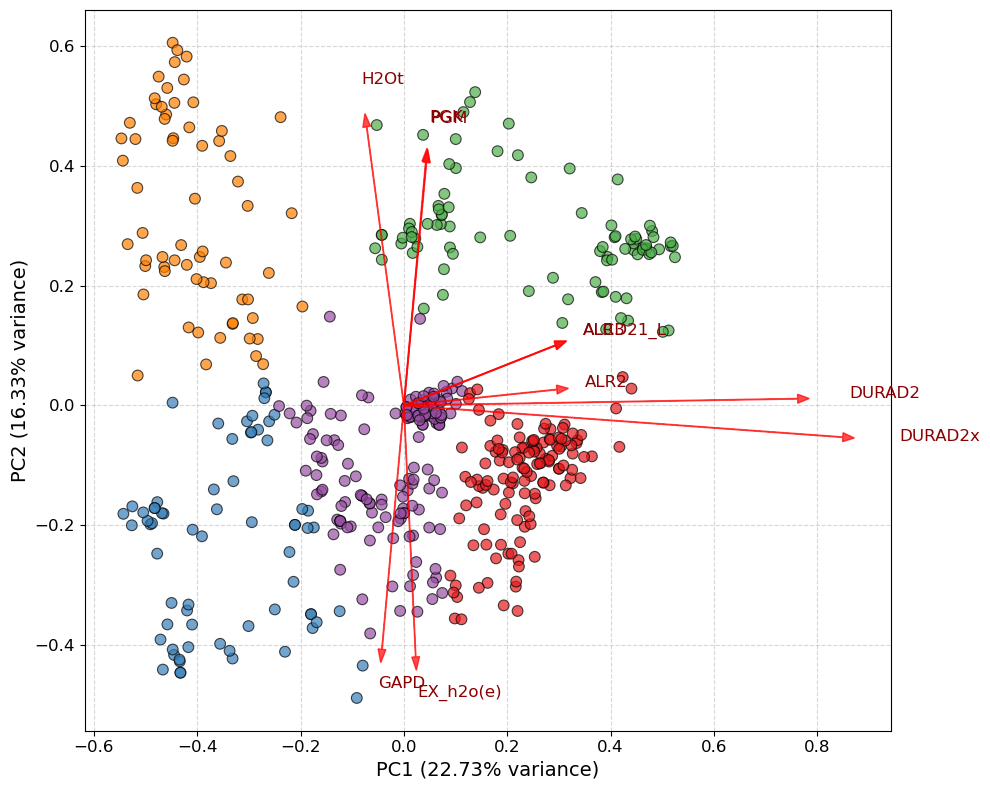

In [5]:
X = normalize(flux_df.T)  # shape: samples × features
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
df_pca = pd.DataFrame(X_pca, index=flux_df.columns, columns=['PC1', 'PC2'])

#here, set k to be whatever was optimal in the elbow plot, this simulation uses k from paper but not same flux_df since this is random
kmeans = KMeans(n_clusters=5, random_state=1, n_init='auto')
kmeans.fit(df_pca)
cluster_labels = pd.DataFrame(kmeans.labels_, index=flux_df.columns, columns=['cluster'])
fig, ax = plt.subplots(figsize=(10, 8))

# build PCA plot
sns.scatterplot(
    data=df_pca,
    x='PC1', y='PC2',
    hue=cluster_labels['cluster'],
    palette='Set1',
    s=60,
    alpha=0.7,
    legend=False,
    edgecolor='black',   # outlines around dots
    linewidth=0.8,
    ax=ax
)

loadings = pd.DataFrame(
    pca.components_.T,  # features × PCs
    index=flux_df.index,
    columns=['PC1', 'PC2']
)

top_features = set(
    loadings['PC1'].abs().sort_values(ascending=False).head(5).index
).union(
    loadings['PC2'].abs().sort_values(ascending=False).head(5).index
)

# Plot top feature loadings as arrows
scale = 1.5  # adjust arrow length
for feature in top_features:
    x_loading = loadings.loc[feature, 'PC1'] * scale
    y_loading = loadings.loc[feature, 'PC2'] * scale
    ax.arrow(0, 0, x_loading, y_loading, color='red', alpha=0.7,
             head_width=0.015, length_includes_head=True)
    ax.text(x_loading * 1.1, y_loading * 1.1, feature, color='darkred', fontsize=12)

# Labels and grid
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)", fontsize=14, color='black')
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)", fontsize=14, color='black')
ax.tick_params(axis='both', labelsize=12, colors='black')
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# Make the outer border (spines) black
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(0.8)

plt.tight_layout()
#plt.savefig('pca_28102025_styled.png', bbox_inches='tight', dpi=300)
plt.show()

In [6]:
#how many solutions fall into each cluster?
print(cluster_labels['cluster'].value_counts())

cluster
3    150
0    128
2     89
1     69
4     64
Name: count, dtype: int64


In [7]:
#how do the loadings correlate with PC1 and PC2?
pc1_loadings = loadings['PC1'].abs().sort_values(ascending=False).head(5)
pc2_loadings = loadings['PC2'].abs().sort_values(ascending=False).head(5)
print(pc1_loadings)
print(pc2_loadings)

reaction_ids
DURAD2x     0.581150
DURAD2      0.522932
ALR2        0.212176
ALCD21_L    0.209720
ALR3        0.209720
Name: PC1, dtype: float64
reaction_ids
H2Ot         0.324923
EX_h2o(e)    0.294799
GAPD         0.286331
PGK          0.286331
PGM          0.285323
Name: PC2, dtype: float64


### Figure 1f

In [8]:
#save cluster labels to a file, and reformat so that reactions are headers of columns and the coefficients of these reactions are the values in each column
#cluster_labels.to_csv('cluster_labels_stationary_5_21102025.csv')
#import reformated file, ready to boxplot the coefficients to find trends with the Kmeans clusters
boxplot = pd.read_csv(r'boxplot_df_stationary_5_22102025.csv') #file name for reformated file (I have used the file from the data in Figure 1a in paper
boxplot = boxplot.set_index('cluster')

                         p_value
Glucose exchange    5.899021e-52
Lactate exchange    7.375469e-27
Ammonia exchange    9.348299e-04
Glutamine exchange  1.639934e-02
Growth rate         5.735837e-01
IgG productivity    9.542863e-01


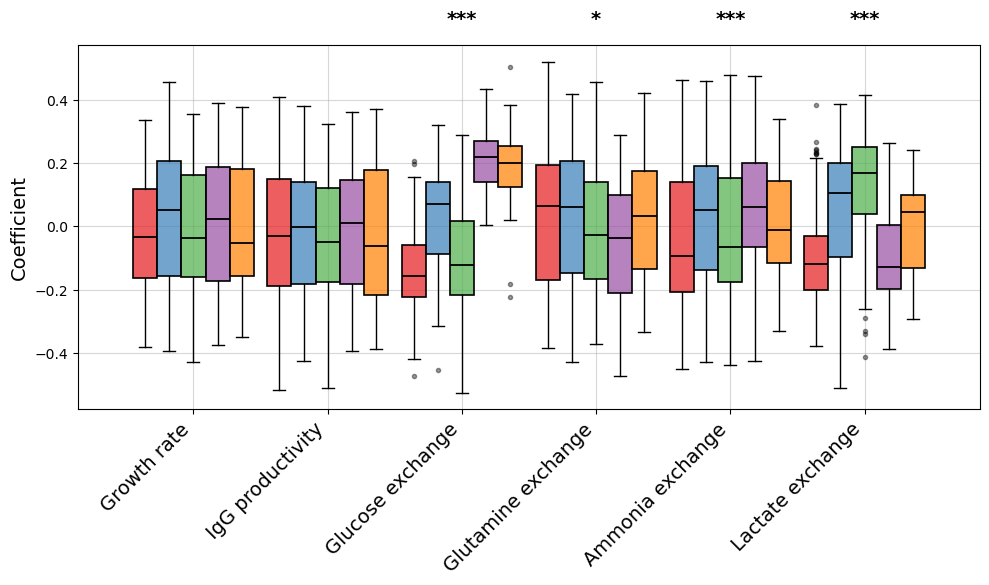

In [9]:
# --- Step 1: Define data and clusters ---
df = boxplot
clusters = sorted(df.index.unique())
reactions = df.columns
width = 0.18  # smaller width for multiple clusters

# --- Step 2: Statistical test (run BEFORE plotting) ---
pvals = {}
for reaction in df.columns:
    groups = [df.loc[c, reaction].dropna() for c in clusters]
    if len(clusters) == 2:
        stat, p = mannwhitneyu(groups[0], groups[1], alternative='two-sided')
    else:
        stat, p = kruskal(*groups)
    pvals[reaction] = p

# Collect p-values into a DataFrame
pvals_df = pd.DataFrame.from_dict(pvals, orient='index', columns=['p_value'])
pvals_df = pvals_df.sort_values('p_value')
print(pvals_df)

# --- Step 3: Plot boxplots ---
palette = sns.color_palette("Set1", n_colors=len(clusters))
colors = {i: (*palette[i], 0.7) for i in clusters}  # add transparency

fig, ax = plt.subplots(figsize=(10, 6))

# Fix spacing between groups
positions = np.arange(len(reactions)) * (len(clusters) * width + 0.1)

for i, cluster in enumerate(clusters):
    cluster_data = df.loc[cluster]
    pos = positions + (i - (len(clusters) - 1) / 2) * width
    ax.boxplot(
        [cluster_data[rxn].dropna() for rxn in reactions],
        positions=pos,
        widths=width,
        patch_artist=True,
        boxprops=dict(facecolor=colors[cluster], color='black', linewidth=1.2),
        medianprops=dict(color='black', linewidth=1.3),
        whiskerprops=dict(color='black'),
        capprops=dict(color='black'),
        flierprops=dict(marker='o', markersize=3, markerfacecolor='black', alpha=0.4)
    )

# --- Step 4: Add significance annotations ---
def significance_label(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

# Calculate Y position for labels
ymax = df.max().max()
y_offset = (df.max().max() - df.min().min()) * 0.1

for i, rxn in enumerate(reactions):
    if rxn not in pvals:
        continue  # skip if missing
    pval = pvals[rxn]
    label = significance_label(pval)
    if label:
        ax.text(
            positions[i],
            ymax + y_offset,
            label,
            ha='center',
            va='bottom',
            fontsize=14,
            color='black',
            fontweight='bold'
        )

# --- Step 5: Formatting ---
ax.set_xticks(positions)
ax.set_xticklabels(reactions, rotation=45, ha='right', fontsize=14)
ax.set_ylabel('Coefficient', fontsize=14)

# Add grid behind plots
ax.grid(True, linestyle='-', alpha=0.5, zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(0.8)

plt.tight_layout()
#plt.savefig('boxplot_6clusters_matchedPCA_28102025.png', bbox_inches='tight', dpi=300)
plt.show()